<a href="https://colab.research.google.com/github/juannMGC/Trabajo-de-Grado/blob/main/PropuestaTGRADO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

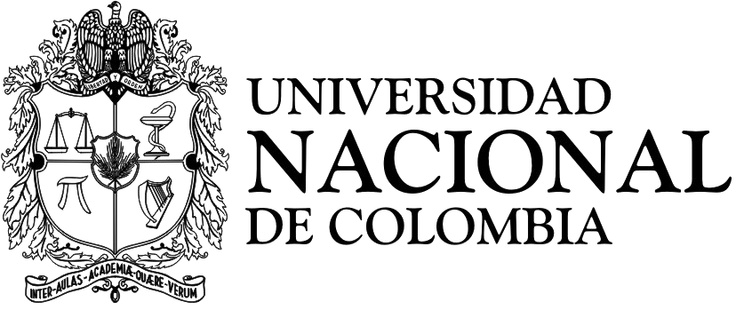
# **Proyecto Final: Machine Learning para predecir el impacto de la calidad del aire en la salud en Manizales.**

**Descripcion**

**Audiencia**

**Preguntas/Problema que buscamos resolver**

**Autor:** Juan Manuel Garcia Cifuentes

**Correo:** jugarciaci@unal.edu.co

# 0. Importación de datos y librerias

In [1]:
# MANIPULACIÓN DE DATOS
import pandas as pd
import numpy as np

# VISUALIZACIÓN
import matplotlib.pyplot as plt
import seaborn as sns

# PREPROCESAMIENTO
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, KFold

# MODELOS
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# MÉTRICAS
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix,
    roc_auc_score,roc_curve,auc
)

# BALANCEO
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# GUARDADO
import joblib


# 1. CARGA Y LIMPIEZA PROFUNDA

In [2]:
df = pd.read_excel('BD_impacto_salud.xlsx')
df.replace(['-200', -200, -200.0, '-200.0', '', ' '], np.nan, inplace=True)

# Limpieza masiva de strings y conversión a float
for feature in df.columns:
    df[feature] = df[feature].astype(str).str.replace(',', '.')
    df[feature] = pd.to_numeric(df[feature], errors='coerce')

# 2. IMPUTACIÓN (Mediana para evitar sesgos por ruido)

In [3]:
# Imputación con mediana
imputer = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

# Categorización basada en la escala recolectada desde la base de datos
def aqi_bin(x):
    x = round(x)
    if x == 0: return 'Buenas'
    elif x == 1: return 'Moderada'
    elif x == 2: return 'Dañina (Grupos Sensitivos)'
    elif x == 3: return 'Dañina a la Salud'
    elif x == 4: return 'Muy Dañina'
    else: return 'Arriesgado'

df_imputed['AQI_Category'] = df_imputed['ICA'].apply(aqi_bin)

# 3. PREPARACIÓN DE DATOS Y BALANCEO (SMOTE, SCALED)

In [4]:
# 1. Separación y Codificación
X = df_imputed.drop(columns=['AQI_Category', 'ICA'])
y = df_imputed['AQI_Category']
le = LabelEncoder()
y_encoded = le.fit_transform(y) # Convertimos a números: 0, 1, 2...

# 2. Balanceo con SMOTE (sobre todo el set antes del split o solo sobre train)
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y_encoded)

# 3. Split
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res,
    test_size=0.2,
    stratify=y_res,
    random_state=42
)

# 4. Escalado (Indispensable para KNN y Redes Neuronales)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. DEFINICIÓN DE LOS 4 MODELOS

In [5]:
# --- Modelo 1: KNN ---
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
print(f"Precisión KNN: {accuracy_score(y_test, y_pred_knn):.4f}")
knn_probs = knn.predict_proba(X_test_scaled)
print("ROC AUC KNN:", roc_auc_score(y_test, knn_probs, multi_class='ovr'))
print(classification_report(y_test, y_pred_knn, target_names=le.classes_))

# --- Modelo 2: Redes Neuronales (MLP) ---
mlp = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
mlp.fit(X_train_scaled, y_train)
y_pred_mlp = mlp.predict(X_test_scaled)
print(f"Precisión Redes Neuronales: {accuracy_score(y_test, y_pred_mlp):.4f}")
mlp_probs = mlp.predict_proba(X_test_scaled)
print("ROC AUC Redes Neuronales:", roc_auc_score(y_test, mlp_probs, multi_class='ovr'))
print(classification_report(y_test, y_pred_mlp, target_names=le.classes_))

# --- Modelo 3: Random Forest ---
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
print(f"Precisión Random Forest: {accuracy_score(y_test, y_pred_rf):.4f}")
rf_probs = rf.predict_proba(X_test_scaled)
print("ROC AUC Random Forest:", roc_auc_score(y_test, rf_probs, multi_class='ovr'))
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

# --- Modelo 4: XGBoost ---
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)
print(f"Precisión XGBoost: {accuracy_score(y_test, y_pred_xgb):.4f}")
xgb_probs = xgb.predict_proba(X_test_scaled)
print("ROC AUC XGBoost:", roc_auc_score(y_test, xgb_probs, multi_class='ovr'))
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

Precisión KNN: 0.5992
ROC AUC KNN: 0.8376333857079609
                            precision    recall  f1-score   support

                Arriesgado       0.64      0.95      0.77        86
                    Buenas       0.71      0.95      0.82        86
Dañina (Grupos Sensitivos)       0.46      0.38      0.42        87
         Dañina a la Salud       0.29      0.16      0.21        87
                  Moderada       0.58      0.49      0.53        87
                Muy Dañina       0.69      0.66      0.67        86

                  accuracy                           0.60       519
                 macro avg       0.56      0.60      0.57       519
              weighted avg       0.56      0.60      0.57       519

Precisión Redes Neuronales: 0.6243
ROC AUC Redes Neuronales: 0.8488068041180205
                            precision    recall  f1-score   support

                Arriesgado       0.88      0.88      0.88        86
                    Buenas       0.92      0.9

  # 4.1. VALIDACION CRUZADA

In [6]:
num_folds = 5

kfold = KFold(n_splits=num_folds, shuffle=True, random_state=42)

models = [
    ('Knn', KNeighborsClassifier()),
    ('Redes Neuronales', MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)),
    ('Random Forest', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('XGBoost', XGBClassifier(random_state=42)),
]

# Metricas
results = []
names = []
print('Metricas \n----------------------\n')
for name, model in models:
    cv_results = cross_val_score(model, X_train_scaled, y_train, cv=kfold, scoring='accuracy')
    results.append(cv_results)
    names.append(name)
    print(f'{name}: {round(cv_results.mean(), 5)} ({round(cv_results.std(), 5)})')


Metricas 
----------------------

Knn: 0.51569 (0.01552)
Redes Neuronales: 0.59289 (0.02572)
Random Forest: 0.6493 (0.0127)
XGBoost: 0.6406 (0.01999)


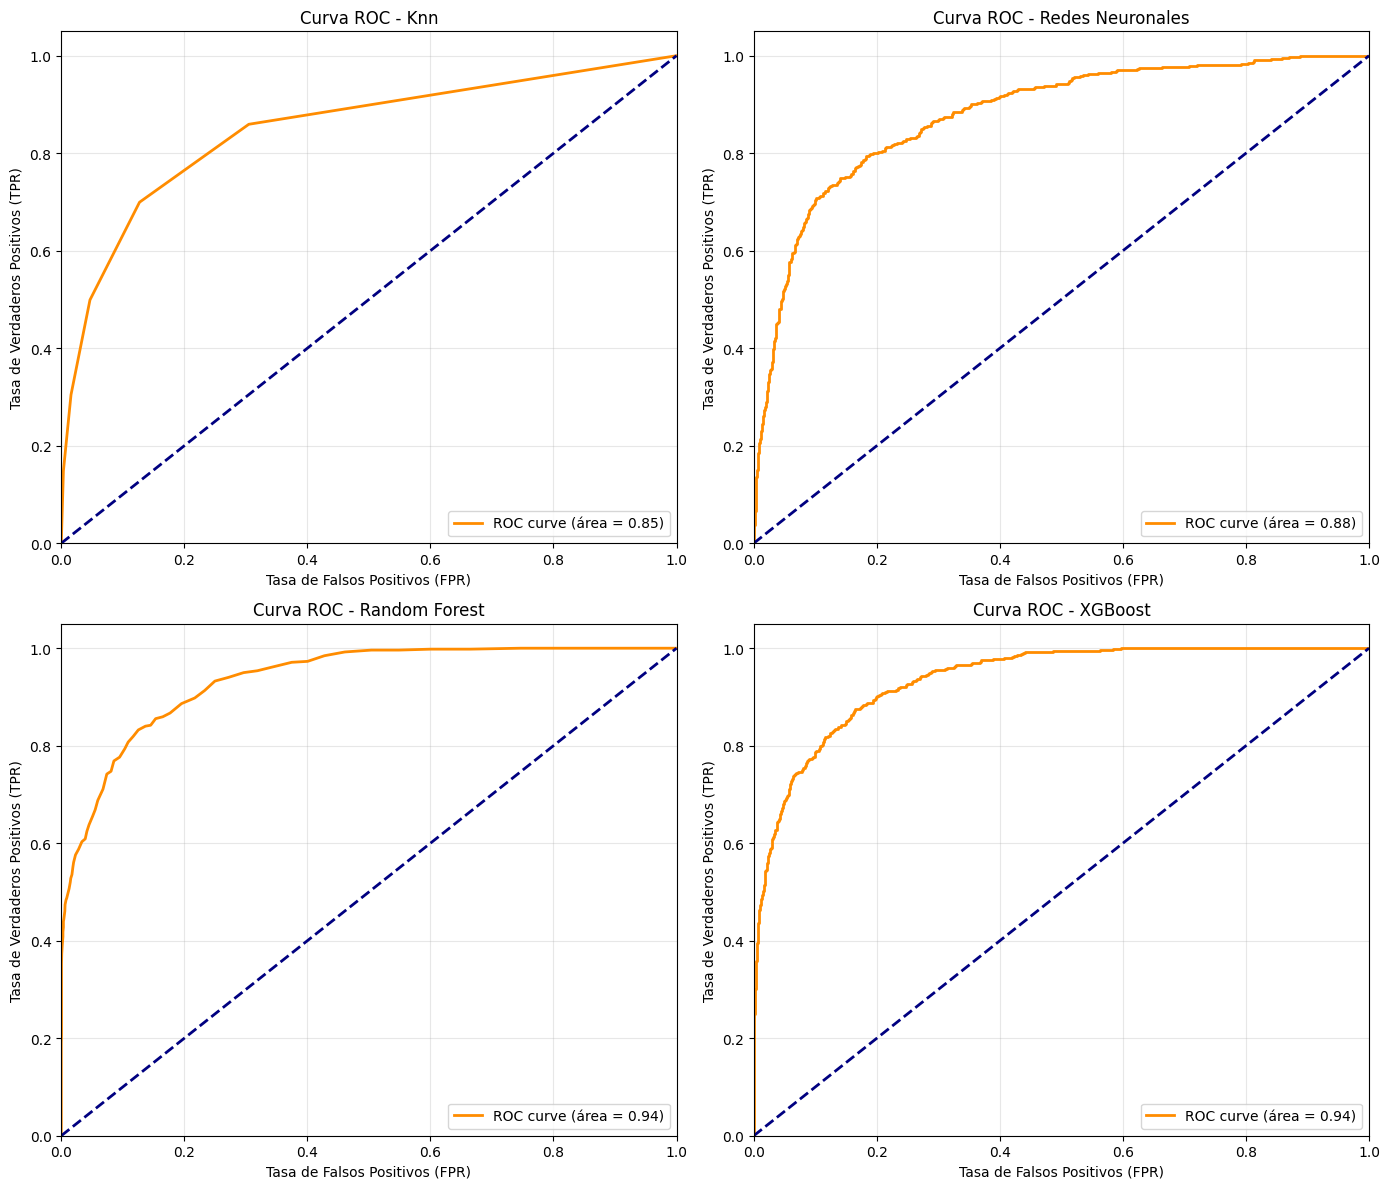

In [7]:
# Binarizamos las etiquetas de prueba para poder graficar cada clase contra las demás
y_test_bin = label_binarize(y_test, classes=np.unique(y_train))
n_classes = y_test_bin.shape[1]

# Definimos los modelos ya entrenados y sus nombres
modelos_entrenados = [
    ('Knn', knn),
    ('Redes Neuronales', mlp),
    ('Random Forest', rf),
    ('XGBoost', xgb)
]

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(14, 12))
axs = axs.flatten()

for i, (name, model) in enumerate(modelos_entrenados):
    y_score = model.predict_proba(X_test_scaled)
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc = auc(fpr, tpr)
    axs[i].plot(fpr, tpr, color='darkorange', lw=2,
                label=f'ROC curve (área = {roc_auc:.2f})')
    axs[i].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

    axs[i].set_xlim([0.0, 1.0])
    axs[i].set_ylim([0.0, 1.05])
    axs[i].set_xlabel('Tasa de Falsos Positivos (FPR)')
    axs[i].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
    axs[i].set_title(f'Curva ROC - {name}')
    axs[i].legend(loc="lower right")
    axs[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 5.OPTIMIZACION Y SELECCION DE  MODELO

In [8]:
param_grids = {
    "Knn": {
        'modelo__n_neighbors': [1, 2, 3],
        'modelo__weights': ['distance', 'uniform'],
        'modelo__metric': ['manhattan', 'euclidean']
    },
    "Redes Neuronales": {
        'modelo__hidden_layer_sizes': [(50,), (100,), (50, 50)],
        'modelo__activation': ['relu', 'logistic'],
        'modelo__alpha': [0.0001, 0.01]
    },
    "Random Forest": {
        'modelo__n_estimators': [100, 200],
        'modelo__max_depth': [None, 20],
        'modelo__min_samples_split': [2, 5]
    },
    "XGBoost": {
        'modelo__n_estimators': [100, 200],
        'modelo__max_depth': [10, 15],
        'modelo__learning_rate': [0.05, 0.1]
    }
}

result = []
best_models = {}

print('--------------------------------------------')

# 2. Búsqueda de hiperparámetros
for name, model in models:
    # Creamos un Pipeline genérico usando 'modelo' como nombre clave
    pipe = Pipeline([('modelo', model)])

    # Configuramos el GridSearchCV
    grid = GridSearchCV(pipe, param_grids[name], cv=5, scoring='accuracy', n_jobs=-1)

    # Entrenamos con los datos balanceados y escalados de Manizales
    grid.fit(X_train_scaled, y_train)

    # Guardamos los resultados
    best_models[name] = grid.best_estimator_
    best_score = grid.best_score_

    # Evaluación en el set de test (datos reales no vistos)
    test_score = grid.score(X_test_scaled, y_test)

    result.append({
        'Modelo': name,
        'Score_Train': round(best_score, 5),
        'Score_Test': round(test_score, 5),
        'Mejores_Params': grid.best_params_
    })

    print(f"{name}")
    print(f"   - Precisión CV: {best_score:.5f}")
    print(f"   - Precisión Test: {test_score:.5f}")
    print('--------------------------------------------')

# 3. Ordenamiento por desempeño en Test (lo más real para tu tesis)
result = sorted(result, key=lambda k: k['Score_Test'], reverse=True)
for res in result:
    print(f"{res['Modelo']}: Train({res['Score_Train']}) | Test({res['Score_Test']})")

--------------------------------------------
Knn
   - Precisión CV: 0.62567
   - Precisión Test: 0.65511
--------------------------------------------
Redes Neuronales
   - Precisión CV: 0.60493
   - Precisión Test: 0.62235
--------------------------------------------
Random Forest
   - Precisión CV: 0.64496
   - Precisión Test: 0.70328
--------------------------------------------
XGBoost
   - Precisión CV: 0.65460
   - Precisión Test: 0.69942
--------------------------------------------
Random Forest: Train(0.64496) | Test(0.70328)
XGBoost: Train(0.6546) | Test(0.69942)
Knn: Train(0.62567) | Test(0.65511)
Redes Neuronales: Train(0.60493) | Test(0.62235)


# 6.IMPORTACION DEL MEJOR MODELO DE PREDICCION PARA VISUALIZACION

In [9]:
# Guardar el ganador absoluto para la App
mejor_modelo_final = best_models[result[0]['Modelo']]
joblib.dump(mejor_modelo_final, 'mejor_modelo.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(X.columns, 'features.pkl')


['features.pkl']

#7. VISUALIZACION EN STREAMLIT

In [13]:
!pip install streamlit
!pip install streamlit-lottie

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 802.4/802.4 kB 17.0 MB/s eta 0:00:00


In [23]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import requests
from streamlit_lottie import st_lottie

# 1. Configuración de la Página y Estilo Visual
st.set_page_config(
    page_title="Investigación Aire Manizales",
    layout="wide",
    page_icon="🏔️"
)

# Función para cargar animaciones Lottie
def cargar_lottie_url(url):
    r = requests.get(url)
    if r.status_code != 200:
        return None
    return r.json()

lottie_salud = cargar_lottie_url("https://lottie.host/3d5ee517-de54-4bf5-a42f-8c87c929dc5c/Bk2pUIGElP.json")
lottie_salud1 = cargar_lottie_url("https://lottie.host/95af0ede-15a3-4890-a1dd-1063b49e88cb/Vik32cUg12.json")

# Estilos personalizados para mejorar la presentación de la tesis
st.markdown("""
    <style>
    .main { background-color: #f8f9fa; }
    .stMetric { background-color: white; padding: 20px; border-radius: 10px; box-shadow: 0 2px 4px rgba(0,0,0,0.05); }
    div[data-testid="stExpander"] { background-color: white; border-radius: 10px; }
    </style>
    """, unsafe_allow_html=True)

# 2. Carga Segura de Activos del Modelo
@st.cache_resource
def load_assets():
    try:
        # Cargamos los archivos generados en el punto 6 del notebook
        model = joblib.load('mejor_modelo.pkl')
        scaler = joblib.load('scaler.pkl')
        le = joblib.load('label_encoder.pkl')
        features = joblib.load('features.pkl')
        return model, scaler, le, features, None
    except Exception as e:
        return None, None, None, None, str(e)

model, scaler, le, features, error = load_assets()

# Validación de carga
if error:
    st.error(f"⚠️ Error Crítico de Carga: {error}")
    st.info("Asegúrate de que los archivos 'mejor_modelo.pkl', 'scaler.pkl', 'label_encoder.pkl' y 'features.pkl' estén en la misma carpeta.")
    st.stop()

with st.sidebar:
    st.header("Estación de Monitoreo") # Opcional: un título
    st_lottie(lottie_salud, speed=1, height=150, key="salud")
    st.sidebar.write("Ajuste los niveles actuales detectados para predecir el impacto en salud pública.")
    #poner lottie de ultimo

    st_lottie(lottie_salud1, speed=1, height=150, key="salud1")

def get_user_inputs():
    input_dict = {}
    # Creamos sliders dinámicos basados estrictamente en las columnas de entrenamiento
    for col in features:
        if 'Humedad' in col:
            input_dict[col] = st.sidebar.slider(f"💧 {col} (%)", 0.0, 100.0, 75.0)
        elif 'Temperatura' in col:
            input_dict[col] = st.sidebar.slider(f"🌡️ {col} (°C)", 0.0, 45.0, 18.0)
        elif 'Hospitalarios' in col or 'Consulta' in col:
            input_dict[col] = st.sidebar.number_input(f"🏥 {col}", min_value=0, value=1)
        else:
            # Contaminantes (PM10, PM2.5, SO2, O3)
            input_dict[col] = st.sidebar.slider(f"💨 {col} (µg/m³)", 0.0, 500.0, 25.0)

    # Aseguramos que el orden de las columnas sea idéntico al entrenamiento
    return pd.DataFrame([input_dict])[features]

df_input = get_user_inputs()

# 4. Cuerpo Principal
st.title("🩺 Proyecto de Investigación: Calidad del Aire en Manizales")
st.markdown("""
    **Metodología de Predicción:** Esta herramienta utiliza inteligencia artificial para evaluar el riesgo sanitario basándose en
    datos atmosféricos y registros de ingresos hospitalarios históricos de la ciudad.
""")

col_params, col_result = st.columns([1, 1])

with col_params:
    st.subheader("📋 Parámetros de Simulación")
    # Mostrar tabla transpuesta para mejor lectura
    st.dataframe(df_input.T.rename(columns={0: 'Valor Actual'}), width='stretch')

with col_result:
    st.subheader("🎯 Clasificación del Impacto")

    # PROCESO DE PREDICCIÓN
    # A. Escalado
    try:
        input_scaled = scaler.transform(df_input)

        # B. Predicción de Clase
        pred_idx = model.predict(input_scaled)[0]
        label = le.inverse_transform([pred_idx])[0]

        # C. Probabilidades
        probs = model.predict_proba(input_scaled)
        confianza = np.max(probs) * 100

        # Mapeo de Colores Estándar ICA (Índice de Calidad del Aire)
        colors = {
            'Buenas': '#28a745',
            'Moderada': '#f1c40f',
            'Dañina (Grupos Sensitivos)': '#fd7e14',
            'Dañina a la Salud': '#dc3545',
            'Muy Dañina': '#6f42c1',
            'Arriesgado': '#343a40'
        }
        res_color = colors.get(label, '#007bff')

        # Tarjeta de Resultado Principal
        st.markdown(f"""
            <div style="background-color:{res_color}; padding:45px; border-radius:20px; text-align:center; color:white; border: 3px solid rgba(255,255,255,0.2);">
                <h1 style="margin:0; font-size:3.8em; font-weight:bold;">{label}</h1>
                <p style="margin:10px 0 0 0; font-size:1.6em; opacity:0.9;">Nivel de Confianza: {confianza:.2f}%</p>
            </div>
        """, unsafe_allow_html=True)

    except Exception as e:
        st.error(f"Error en la predicción: {e}")

# 5. Visualización de Probabilidades
st.write("---")
st.subheader("📊 Análisis de Incertidumbre del Modelo")
st.write("Distribución de probabilidad para cada categoría de impacto:")

# Preparar datos para el gráfico de barras
prob_df = pd.DataFrame(probs, columns=le.classes_).T
prob_df.columns = ['Probabilidad (%)']
prob_df['Probabilidad (%)'] = prob_df['Probabilidad (%)'] * 100

st.bar_chart(prob_df, width='stretch')

# Pie de página académico
st.caption("Investigación sobre Machine Learning aplicado a la Salud Ambiental - Manizales, 2025.")

Overwriting app.py


In [12]:
!pip install pyngrok
from pyngrok import ngrok

# 1. Configura tu token (Solo se hace una vez)
!ngrok config add-authtoken 37Witr0TOo9qsHwPAPzDrh9jEk3_5e16FFvrECqnUhfVfkiep

# 2. Lanza Streamlit en segundo plano
import os
os.system("streamlit run app.py &")

# 3. Crea el túnel estable
public_url = ngrok.connect(8501)
print(f"Enlace: {public_url.public_url}")

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml
Enlace: https://34fef0ff4619.ngrok-free.app
